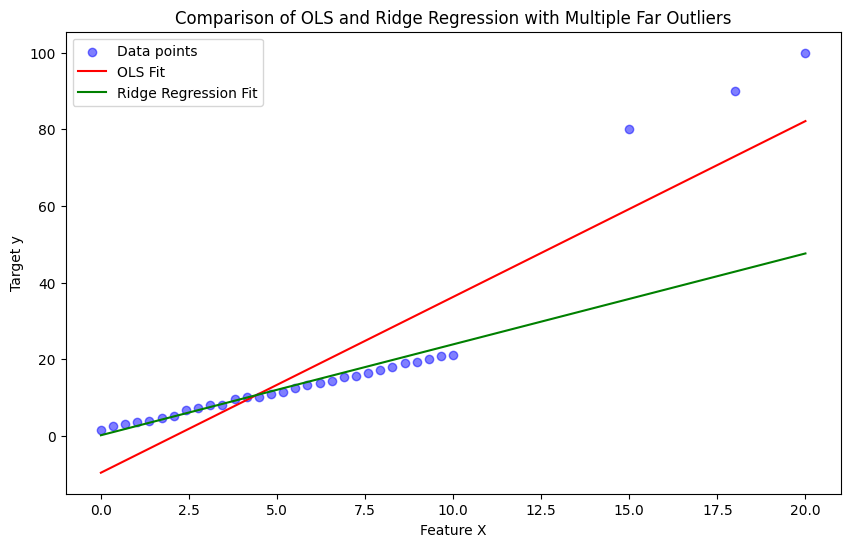

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# set a random seed for reproducability
np.random.seed(42)  # For reproducibility

# generate a simple linear dataset
n_samples =30
X_input = np.linspace(0,10,n_samples)
y= 2 * X_input + 1 + np.random.rand(n_samples) # true slope =2 , intercept = 1 , some noise

# add three impactful outliers
X_input = np.append(X_input,[15,18,20]) # farther on the x-axis
y = np.append(y,[80,90,100]) # much higher y values

# add the intercept term
X = np.hstack([np.ones((n_samples + 3,1)),X_input.reshape(-1,1)])

# compute the ols and the radge regresion solutions
beta_OLS = np.linalg.inv(X.T @ X) @ X.T @ y
lambda_ridge = 1000 # a stronger lambda to emphasize ridge's dampeneing effect
I = np.eye(X.shape[1])
beta_Ridge = np.linalg.inv(X.T @ X + lambda_ridge * I) @ X.T @ y

# prepare to plot
plt.figure(figsize=(10,6))
plt.scatter(X_input,y,color='blue',alpha=0.5,label='Data points')

# plot the OLS fit
x_range = np.linspace(np.min(X_input),np.max(X_input),100)
y_OLS = beta_OLS[0] + beta_OLS[1] * x_range
plt.plot(x_range,y_OLS,'r-',label='OLS Fit')

# plot the Ridhe Regression fit
y_Ridge = beta_Ridge[0] + beta_Ridge[1] * x_range
plt.plot(x_range,y_Ridge,'g-',label='Ridge Regression Fit')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Comparison of OLS and Ridge Regression with Multiple Far Outliers')
plt.legend()
plt.show()
